In [21]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

## DATA LOAD & PREPROCESSING

In [355]:
file_path = 'time_series_60min_singleindex.csv'

countries = ["CZ", "DE", "AT", "PL"]

target_columns = ["utc_timestamp"]
for c in countries:
    target_columns += [
        f"{c}_load_actual_entsoe_transparency",
        f"{c}_solar_generation_actual",
        f"{c}_wind_onshore_generation_actual"
    ]

df = pd.read_csv(file_path, usecols=target_columns, index_col=0, parse_dates=True)
df.index = df.index.tz_localize(None)

df_2019 = df.loc['2019-01-01':'2019-12-31'].copy().ffill().bfill().fillna(0)

# --- TECH DATA ---
def annuity(n, r):
    if r > 0:        
        return r / (1 - 1/(1+r)**n)
    else:
        return 1 / n

discount_rate = 0.07

# Gas marginal cost calculation
# Source: #https://www.sciencedirect.com/science/article/abs/pii/S036054421831288X?fr=RR-2&ref=pdf_download&rr=9ea337d92f634f62
fuel_cost_gas = 21.6 
vom_gas = 3.0        
gas_marginal = (fuel_cost_gas / 0.39) + vom_gas # 0.39 from gas efficiency

# Costs and parameters for each technology
# Source: #https://www.diw.de/documents/publikationen/73/diw_01.c.424566.de/diw_datadoc_2013-068.pdf
# Source: https://www.woodwayenergy.com/natural-gas-efficiency-in-power-generation/
tech_data = {
    'solar':       {'inv': 750000,  'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#f1c40f"},
    'wind':        {'inv': 1240000, 'fom': 0.03, 'life': 25, 'marg': 0.01,          'eff': 1.00,                            'color': "#3498db"},
    'nuclear':     {'inv': 6000000, 'fom': 0.025,'life': 40, 'marg': 11.5,          'eff': 1.00, 'avail': 0.9,              'color': "#e74c3c"},
    'coal':        {'inv': 1300000, 'fom': 0.02, 'life': 40, 'marg': 51.0,          'eff': 0.33, 'avail': 1.0, 'co2': 0.34, 'color': "#7f8c8d"},
    'gas':         {'inv': 400000,  'fom': 0.04, 'life': 30, 'marg': gas_marginal,  'eff': 0.39, 'avail': 1.0, 'co2': 0.19, 'color': "#e67e22"}
} # should we change eff?

# Installed capacities of solar and wind of each country for CF scaling
# Source: #https://transparency.entsoe.eu/generation/installed/perType?appState=%7B%22sa%22%3A%5B%22BZN%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22BZN%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22CHART%22%2C%22df%22%3A%5B%222019%22%2C%222019%22%5D%2C%22tz%22%3A%22CET%22%7D
installed = {
    "CZ": {"solar": 2049,   "wind": 316},
    "DE": {"solar": 45435,  "wind": 52946},
    "PL": {"solar": 430,    "wind": 5808},
    "AT": {"solar": 1193,   "wind": 3035},
} 

# Capacity factors of solar and wind of each country
for c in countries:
    df_2019[f"{c}_solar_cf"] = (
        df_2019[f"{c}_solar_generation_actual"] / installed[c]["solar"]
    ).clip(0, 1)

    df_2019[f"{c}_wind_cf"] = (
        df_2019[f"{c}_wind_onshore_generation_actual"] / installed[c]["wind"]
    ).clip(0, 1)

## NETWORK

In [356]:
# --- NETWORK MODEL ---
n = pypsa.Network()
n.set_snapshots(df_2019.index)

# Buses
n.add("Bus", countries)

# Gas buses
for c in countries:
    n.add("Bus", f"{c}_gas")

# Carriers
for tech, d in tech_data.items():
    n.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

n.add("Carrier", "ch4", co2_emissions=0.19, color="#a75610")

# --- LOADS ---
for c in countries:
    n.add("Load", f"{c}_load",
          bus=c,
          p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        if tech == "gas":
            continue  # Gas will be added as a separate generator on DE gas bus

        name = f"{c}_{tech}"

        # Costs
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        # Marginal cost + CF
        if  tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]
            efficiency = d["eff"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]
            efficiency = d["eff"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]
            efficiency = d["eff"]

        n.add("Generator",
              name,
              bus = c,
              carrier = tech,
              p_nom_extendable = True,
              capital_cost = capital_cost,
              marginal_cost = marginal_cost,
              efficiency = efficiency,
              p_max_pu = p_max_pu)

# Gas supply for DE gas bus        
n.add("Generator", "DE_gas_supply",
      bus = "DE_gas",
      carrier = "ch4",
      p_nom_extendable = True,
      capital_cost = 400000 * (annuity(30, discount_rate) + 0.04),
      marginal_cost = gas_marginal,
      efficiency = 0.39, # Gas supply is modelled as a commodity supply, not a generator, so efficiency is 1.
      p_max_pu = 1.0)

# --- TRANSMISSION ---
# Capacities based on 2026 max physical flows between the countries
# Source: #https://transparency.entsoe.eu/transmission/physicalFlows?appState=%7B%22sa%22%3A%5B%22CTY%7C10YCZ-CEPS-----N%22%5D%2C%22st%22%3A%22CTY%22%2C%22mm%22%3Atrue%2C%22ma%22%3Afalse%2C%22sp%22%3A%22HALF%22%2C%22dt%22%3A%22TABLE%22%2C%22df%22%3A%222026-04-01%22%2C%22tz%22%3A%22CET%22%7D
lines = [
    ("CZ", "DE", 3500), # max: 3449
    ("CZ", "AT", 2500), # max: 2390
    ("CZ", "PL", 2500), # max: 2487
    ("DE", "PL", 3000), # max: 2820
]

# Add electrical lines
for b0, b1, cap in lines:
    n.add("Line", f"{b0}-{b1}", 
          bus0=b0, 
          bus1=b1, 
          x=1, 
          s_nom=cap)

# Add gas pipelines
gas_pipe_connections = [
    ("DE", c) for c in countries if c != "DE"
]

for b0, b1 in gas_pipe_connections:
    n.add("Link", f"{b0}-{b1}_gas_pipe",
          bus0=f"{b0}_gas",
          bus1=f"{b1}_gas",
          p_nom_extendable=True,
          p_min_pu=-1,
          efficiency=0.98)

# Add gas-to-power conversion links    
for c in countries:
    n.add("Link", f"{c}_gas_to_power",
          bus0=f"{c}_gas",
          bus1=c,
          p_nom_extendable=True,
          marginal_cost=0) # Marginal cost is 0 because fuel cost is accounted in the gas supply generator

# --- OPTIMIZATION ---
n.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_10640\1206038261.py:112: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL', 'CZ_gas', 'DE_gas', 'AT_gas', 'PL_gas'], dtype='str', name='name')
Index(['DE-CZ_gas_pipe', 'DE-AT_gas_pipe', 'DE-PL_gas_pipe', 'CZ_gas_to_power',
       'DE_gas_to_power', 'AT_gas_to_power', 'PL_gas_to_power'],
      dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 65.42it/s]
INFO:linopy.io: Writing time: 1.23s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 101520 iterations and 7.39 seconds (4.25 work units)


INFO:gurobipy:Solved in 101520 iterations and 7.39 seconds (4.25 work units)


Optimal objective  5.188751497e+10


INFO:gurobipy:Optimal objective  5.188751497e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 245304 primals, 569424 duals
Objective: 5.19e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')

## Single Gas Bus (DE)

In [32]:
# --- NETWORK MODEL ---
n2 = pypsa.Network()
n2.set_snapshots(df_2019.index)

# Electricity buses
n2.add("Bus", countries)

# SINGLE gas bus
n2.add("Bus", "DE_gas")

# Carriers
for tech, d in tech_data.items():
    n2.add("Carrier", tech, co2_emissions=d.get("co2", 0), color=d["color"])

n2.add("Carrier", "ch4", co2_emissions=0.19, color="#e67e22")

# --- LOADS ---
for c in countries:
    n2.add("Load", f"{c}_load",
           bus=c,
           p_set=df_2019[f"{c}_load_actual_entsoe_transparency"])

# --- GENERATORS ---
for c in countries:
    for tech, d in tech_data.items():

        if tech == "gas":
            continue

        name = f"{c}_{tech}"
        capital_cost = d['inv'] * (annuity(d['life'], discount_rate) + d['fom'])

        if tech == "wind":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_wind_cf"]

        elif tech == "solar":
            marginal_cost = d["marg"]
            p_max_pu = df_2019[f"{c}_solar_cf"]

        else:
            marginal_cost = d["marg"]
            p_max_pu = d["avail"]

        n2.add("Generator",
               name,
               bus=c,
               carrier=tech,
               p_nom_extendable=True,
               capital_cost=capital_cost,
               marginal_cost=marginal_cost,
               efficiency=d["eff"],
               p_max_pu=p_max_pu)

# --- GAS SUPPLY ---
n2.add("Generator", "DE_gas_supply",
       bus="DE_gas",
       carrier="ch4",
       p_nom_extendable=True,
       marginal_cost=fuel_cost_gas)

# --- ELECTRICITY TRANSMISSION ---
lines = [
    ("CZ", "DE", 3500),
    ("CZ", "AT", 2500),
    ("CZ", "PL", 2500),
    ("DE", "PL", 3000),
]

for b0, b1, cap in lines:
    n2.add("Line", f"{b0}-{b1}",
           bus0=b0,
           bus1=b1,
           x=1,
           s_nom=cap)

# --- GAS TO POWER ---
for c in countries:
    n2.add("Link", f"{c}_gas_to_power",
           bus0="DE_gas",
           bus1=c,
           efficiency=0.39,
           p_nom_extendable=True,
           capital_cost=tech_data["gas"]["inv"] *
                        (annuity(tech_data["gas"]["life"], discount_rate) + tech_data["gas"]["fom"]),
           marginal_cost=0)

# --- OPTIMIZATION ---
n2.optimize(solver_name="gurobi")

C:\Users\Bagus\AppData\Local\Temp\ipykernel_52864\3263682582.py:89: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['CZ', 'DE', 'AT', 'PL', 'DE_gas'], dtype='str', name='name')
Index(['CZ_gas_to_power', 'DE_gas_to_power', 'AT_gas_to_power',
       'PL_gas_to_power'],
      dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
Index(['CZ-DE', 'CZ-AT', 'CZ-PL', 'DE-PL'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 80.64it/s]
INFO:linopy.io: Writing time: 1.1s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2794134


INFO:gurobipy:Set parameter LicenseID to value 2794134


...

Solved in 167237 iterations and 8.27 seconds (5.01 work units)


INFO:gurobipy:Solved in 167237 iterations and 8.27 seconds (5.01 work units)


Optimal objective  5.536271382e+10


INFO:gurobipy:Optimal objective  5.536271382e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 219021 primals, 490581 duals
Objective: 5.54e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, Kirchhoff-Voltage-Law were not assigned to the network.


('ok', 'optimal')

## OUTPUT

### Metrics

In [395]:
print(f"\nTotal System Cost: {n.objective/1e6:.2f} M€")

# print("\nCapacities:")
# print(n.generators.p_nom_opt)

# # --- 10. METRICS ---
# print("\n--- SYSTEM METRICS ---")

# total_demand = n.loads_t.p_set.sum().sum()
# total_gen = n.generators_t.p.sum().sum()

# print(f"Total Demand: {total_demand/1e6:.2f} TWh")
# print(f"Total Generation: {total_gen/1e6:.2f} TWh")

# # CO2
# co2 = 0
# for g in n.generators.index:
#     carrier = n.generators.at[g, "carrier"]
#     co2_int = n.carriers.at[carrier, "co2_emissions"]
#     eff = n.generators.at[g, "efficiency"]
#     gen = n.generators_t.p[g].sum()
#     co2 += gen * co2_int / eff

# print(f"CO2 Emissions: {co2/1e6:.2f} Mt")

# # Renewable share
# renewables = ["solar", "wind"]
# ren_gen = sum(
#     n.generators_t.p[g].sum()
#     for g in n.generators.index
#     if n.generators.at[g, "carrier"] in renewables
# )

# print(f"Renewable Share: {ren_gen/total_gen:.2%}")

# # LCOE
# print(f"System LCOE: {n.objective/total_demand:.2f} EUR/MWh")


Total System Cost: 51887.51 M€


### Plots

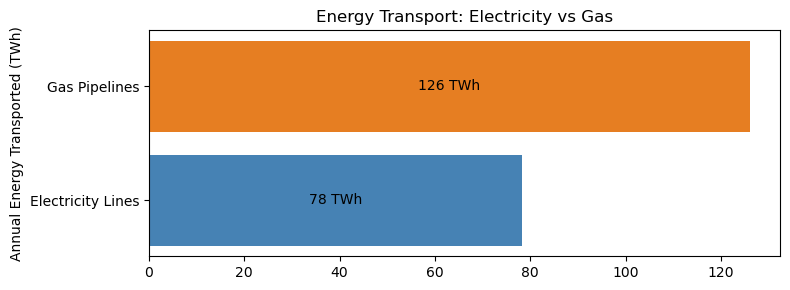

Electricity lines : 78 TWh
Gas pipelines     : 126 TWh


In [381]:
gas_pipes   = [l for l in n.links.index if l.endswith("_gas_pipe")]
gas_to_pow  = [l for l in n.links.index if l.endswith("_gas_to_power")]
elec_lines  = list(n.lines.index)

elec_flow_TWh = (n.lines_t.p0.abs()).sum().sum() / 1e6
gas_flow_TWh  = (n.links_t.p0[gas_pipes].abs()).sum().sum() / 1e6

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(["Electricity Lines", "Gas Pipelines"],
              [elec_flow_TWh, gas_flow_TWh],
              color=["steelblue", "#e67e22"])

ax.bar_label(bars, fmt="%.0f TWh", padding=0, label_type="center")
ax.set_ylabel("Annual Energy Transported (TWh)")
ax.set_title("Energy Transport: Electricity vs Gas")
plt.tight_layout()
plt.show()

print(f"Electricity lines : {elec_flow_TWh:,.0f} TWh")
print(f"Gas pipelines     : {gas_flow_TWh:,.0f} TWh")

In [382]:
# Gas pipeline capacities
print("\n--- Optimal Gas Pipeline Capacities ---")
print(n.links.loc[gas_pipes, "p_nom_opt"].rename("p_nom_opt (MW)").to_string())

# Gas-to-power capacities
print("\n--- Optimal Gas-to-Power Capacities ---")
print(n.links.loc[gas_to_pow, "p_nom_opt"].rename("p_nom_opt (MW)").to_string())


--- Optimal Gas Pipeline Capacities ---
name
DE-CZ_gas_pipe     7258.969388
DE-AT_gas_pipe     8404.248280
DE-PL_gas_pipe    22674.675379

--- Optimal Gas-to-Power Capacities ---
name
CZ_gas_to_power     7113.790000
DE_gas_to_power    82811.000000
AT_gas_to_power     8236.163314
PL_gas_to_power    22221.181872


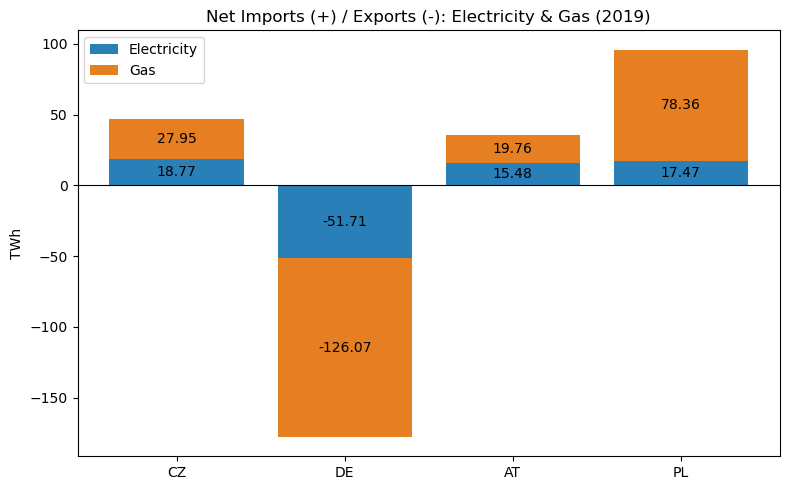

In [383]:
net_elec_imports = {c: 0 for c in countries}
net_gas_imports = {c: 0 for c in countries}

# Electricity lines
for line in n.lines.index:
    bus0 = n.lines.at[line, "bus0"]
    bus1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]
    net_elec_imports[bus0] -= flow.sum()
    net_elec_imports[bus1] += flow.sum()

# Gas pipelines
gas_pipes = [l for l in n.links.index if l.endswith("_gas_pipe")]
for pipe in gas_pipes:
    bus0 = n.links.at[pipe, "bus0"]
    bus1 = n.links.at[pipe, "bus1"]
    c0 = bus0.replace("_gas", "")
    c1 = bus1.replace("_gas", "")
    flow = n.links_t.p0[pipe]
    net_gas_imports[c0] -= flow.sum()
    net_gas_imports[c1] += flow.sum()

net_elec_imports = pd.Series(net_elec_imports) / 1e6  # TWh
net_gas_imports  = pd.Series(net_gas_imports)  / 1e6  # TWh

fig, ax = plt.subplots(figsize=(8, 5))

bars_e = ax.bar(countries, net_elec_imports.values,
                color="#2980b9", label="Electricity")
bars_g = ax.bar(countries, net_gas_imports.values,
                bottom=net_elec_imports.values,
                color="#e67e22", label="Gas")

ax.bar_label(bars_e, fmt="%.2f", label_type="center")
ax.bar_label(bars_g, fmt="%.2f", label_type="center")

ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("TWh")
ax.set_title("Net Imports (+) / Exports (-): Electricity & Gas (2019)")
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

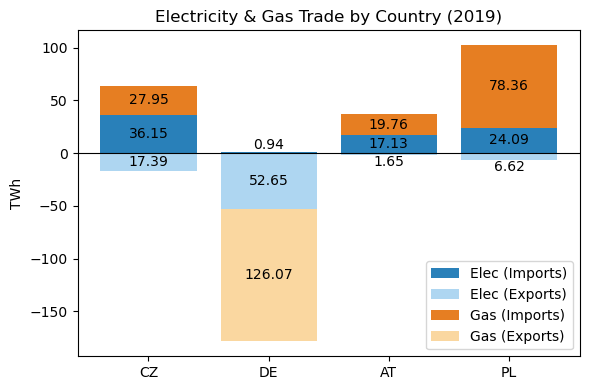

In [384]:
imports_elec = {c: 0 for c in countries}
exports_elec = {c: 0 for c in countries}
imports_gas  = {c: 0 for c in countries}
exports_gas  = {c: 0 for c in countries}

# Electricity lines
for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    flow = n.lines_t.p0[line]

    exports_elec[b0] += flow.clip(lower=0).sum()
    imports_elec[b1] += flow.clip(lower=0).sum()
    exports_elec[b1] += (-flow).clip(lower=0).sum()
    imports_elec[b0] += (-flow).clip(lower=0).sum()

# Gas pipelines
gas_pipes = [l for l in n.links.index if l.endswith("_gas_pipe")]
for pipe in gas_pipes:
    b0 = n.links.at[pipe, "bus0"].replace("_gas", "")
    b1 = n.links.at[pipe, "bus1"].replace("_gas", "")
    flow = n.links_t.p0[pipe]

    exports_gas[b0] += flow.clip(lower=0).sum()
    imports_gas[b1] += flow.clip(lower=0).sum()
    exports_gas[b1] += (-flow).clip(lower=0).sum()
    imports_gas[b0] += (-flow).clip(lower=0).sum()

imports_elec =  pd.Series(imports_elec) / 1e6
exports_elec = -pd.Series(exports_elec) / 1e6  # negative
imports_gas  =  pd.Series(imports_gas)  / 1e6
exports_gas  = -pd.Series(exports_gas)  / 1e6  # negative

x = range(len(countries))
width = 0.8

fig, ax = plt.subplots(figsize=(6, 4))

bars_i_e = ax.bar(x, imports_elec, width, color="#2980b9", label="Elec (Imports)")
bars_e_e = ax.bar(x, exports_elec, width, color="#aed6f1", label="Elec (Exports)")

bars_i_g = ax.bar(x, imports_gas,  width, bottom=imports_elec,
                  color="#e67e22", label="Gas (Imports)")
bars_e_g = ax.bar(x, exports_gas,  width, bottom=exports_elec,
                  color="#fad7a0", label="Gas (Exports)")

MIN_LABEL = 15

for container, color in [(bars_i_e, "white"), (bars_i_g, "black"),
                          (bars_e_e, "white"), (bars_e_g, "black")]:
    for bar in container:
        height = bar.get_height()
        if abs(height) > 0.05:
            if abs(height) < MIN_LABEL:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height + (0.05 if height > 0 else -0.05),
                    f"{abs(height):.2f}",
                    ha="center", va="bottom" if height > 0 else "top",
                )
            else:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{abs(height):.2f}",
                    ha="center", va="center",
                )

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel("TWh")
ax.set_title("Electricity & Gas Trade by Country (2019)")
ax.legend()
plt.tight_layout()
plt.show()

In [385]:
flow_df = pd.DataFrame(0.0, index=countries, columns=countries)

for line in n.lines.index:
    b0 = n.lines.at[line, "bus0"]
    b1 = n.lines.at[line, "bus1"]
    
    flow = n.lines_t.p0[line]

    # energy in TWh
    b0_to_b1 = flow.clip(lower=0).sum() / 1e6
    b1_to_b0 = (-flow).clip(lower=0).sum() / 1e6

    flow_df.loc[b0, b1] += b0_to_b1
    flow_df.loc[b1, b0] += b1_to_b0

flow_df = flow_df.round(2)
flow_df["Total Export"] = flow_df.sum(axis=1)
flow_df.loc["Total Import"] = flow_df.sum(axis=0)

flow_df

,CZ,DE,AT,PL,Total Export
CZ,0.00,0.09,17.13,0.17,17.39
DE,28.74,0.00,0.00,23.92,52.66
AT,1.65,0.00,0.00,0.00,1.65
PL,5.77,0.86,0.00,0.00,6.63
Total Import,36.16,0.95,17.13,24.09,78.33


In [386]:
gas_flow_df = pd.DataFrame(0.0, index=countries, columns=countries)

gas_to_power = [l for l in n.links.index if l.endswith("_gas_to_power")]

for pipe in gas_to_power:
    b0 = n.links.at[pipe, "bus0"].replace("_gas", "")
    b1 = n.links.at[pipe, "bus1"].replace("_gas", "")

    flow = n.links_t.p0[pipe]

    b0_to_b1 = flow.clip(lower=0).sum() / 1e6
    b1_to_b0 = (-flow).clip(lower=0).sum() / 1e6

    gas_flow_df.loc[b0, b1] += b0_to_b1
    gas_flow_df.loc[b1, b0] += b1_to_b0

gas_flow_df = gas_flow_df.round(2)
gas_flow_df["Total Export"] = gas_flow_df.sum(axis=1)
gas_flow_df.loc["Total Import"] = gas_flow_df.sum(axis=0)

gas_flow_df

,CZ,DE,AT,PL,Total Export
CZ,27.39,0.00,0.00,0.00,27.39
DE,0.00,542.18,0.00,0.00,542.18
AT,0.00,0.00,19.36,0.00,19.36
PL,0.00,0.00,0.00,76.79,76.79
Total Import,27.39,542.18,19.36,76.79,665.72


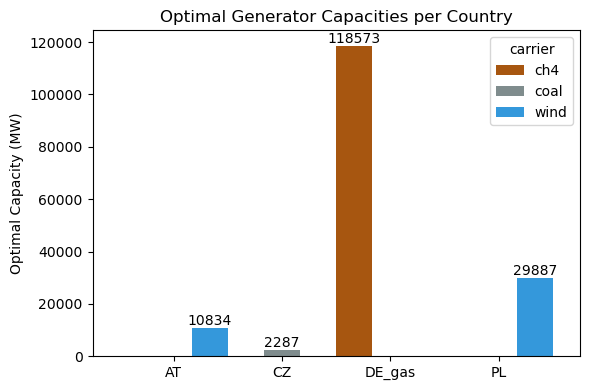

In [387]:
gen_caps = n.generators[["bus", "carrier", "p_nom_opt"]].copy()
gen_caps = gen_caps[gen_caps["p_nom_opt"] > 1]

pivot = gen_caps.pivot_table(index="bus", columns="carrier", values="p_nom_opt", aggfunc="sum")

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot.bar(ax=ax,
               color=[n.carriers.at[c, "color"] for c in pivot.columns],
               width=1)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height + 10,
                f"{height:.0f}",
                ha="center", va="bottom"
            )

ax.set_ylabel("Optimal Capacity (MW)")
ax.set_title("Optimal Generator Capacities per Country")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [388]:
g2p_caps

,bus,carrier,p_nom_opt
CZ_gas_to_power,CZ,gas,7113.790000
DE_gas_to_power,DE,gas,82811.000000
AT_gas_to_power,AT,gas,8236.163314
PL_gas_to_power,PL,gas,22221.181872


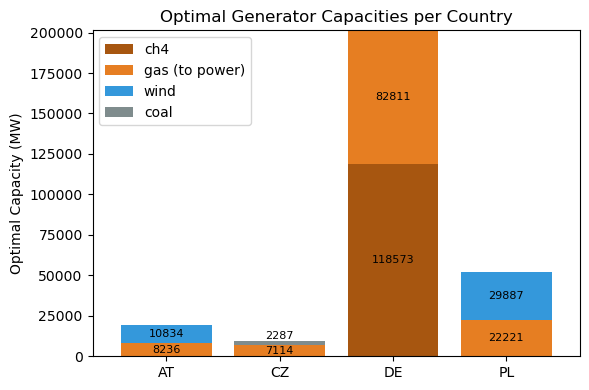

In [389]:
gen_caps = n.generators[["bus", "carrier", "p_nom_opt"]].copy()
gen_caps = gen_caps[gen_caps["p_nom_opt"] > 1]

# Add gas-to-power link capacities
gas_to_pow = [l for l in n.links.index if l.endswith("_gas_to_power")]
g2p_caps = pd.DataFrame({
    "bus": [n.links.at[l, "bus1"] for l in gas_to_pow],
    "carrier": "gas",
    "p_nom_opt": [n.links.at[l, "p_nom_opt"] for l in gas_to_pow]
}, index=gas_to_pow)
g2p_caps = g2p_caps[g2p_caps["p_nom_opt"] > 1]

gen_caps = pd.concat([gen_caps, g2p_caps])

gen_caps["bus"] = gen_caps["bus"].str.replace("_gas", "")

pivot = gen_caps.pivot_table(index="bus", columns="carrier", values="p_nom_opt", aggfunc="sum")

# Reorder columns
desired_order = ["nuclear", "solar", "ch4", "gas", "wind", "coal"]
ordered_cols = [c for c in desired_order if c in pivot.columns]

pivot = pivot[ordered_cols]

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot.bar(ax=ax, stacked=True,
               color=[n.carriers.at[c, "color"] for c in pivot.columns],
               width=0.8)

MIN_SEGMENT = 3000  

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 1:
            y = bar.get_y() + height / 2
            # if segment is too small, push label above the bar
            if height < MIN_SEGMENT:
                y = bar.get_y() + height + 200
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y,
                f"{height:.0f}",
                ha="center", va="bottom" if height < MIN_SEGMENT else "center",
                fontsize=8
            )

ax.set_ylabel("Optimal Capacity (MW)")
ax.set_title("Optimal Generator Capacities per Country")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)

handles, labels = ax.get_legend_handles_labels()
labels = ["gas (to power)" if l == "gas" else l for l in labels]
ax.legend(handles, labels)

plt.tight_layout()
plt.show()

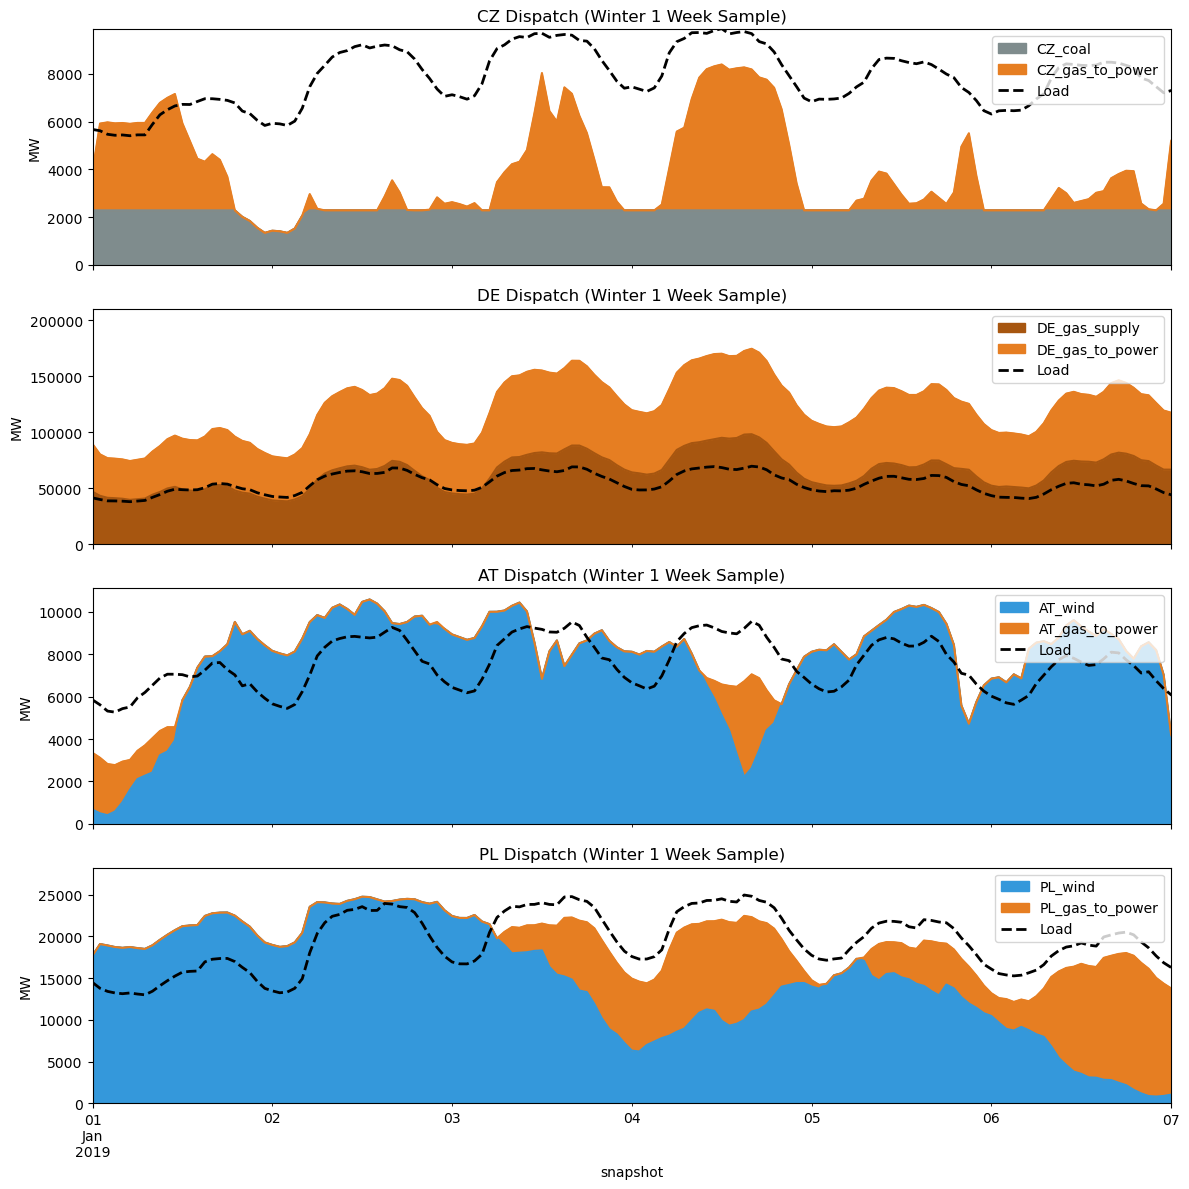

In [390]:
SIGNIFICANCE_THRESHOLD = 0.01

# --- DISPATCH PLOT (WINTER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]
    gen_dispatch = n.generators_t.p[gens]
    
    # Gas-to-power output
    gas_to_pow = f"{c}_gas_to_power"
    gas_dispatch = -n.links_t.p1[gas_to_pow] if gas_to_pow in n.links.index else pd.Series(0, index=n.snapshots)

    total = gen_dispatch.sum().sum() + gas_dispatch.sum()
    significant_gens = [g for g in gens if gen_dispatch[g].sum() / total > SIGNIFICANCE_THRESHOLD]

    # Build combined dataframe for area plot
    plot_df = gen_dispatch[significant_gens].copy()
    if gas_dispatch.sum() / total > SIGNIFICANCE_THRESHOLD:
        plot_df[f"{c}_gas_to_power"] = gas_dispatch.values

    colors = [n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in significant_gens]
    if f"{c}_gas_to_power" in plot_df.columns:
        colors.append(tech_data["gas"]["color"])

    plot_df.plot.area(ax=ax, color=colors)

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Winter 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

plt.xlim("2019-01-01", "2019-01-07")
plt.tight_layout()
plt.show()

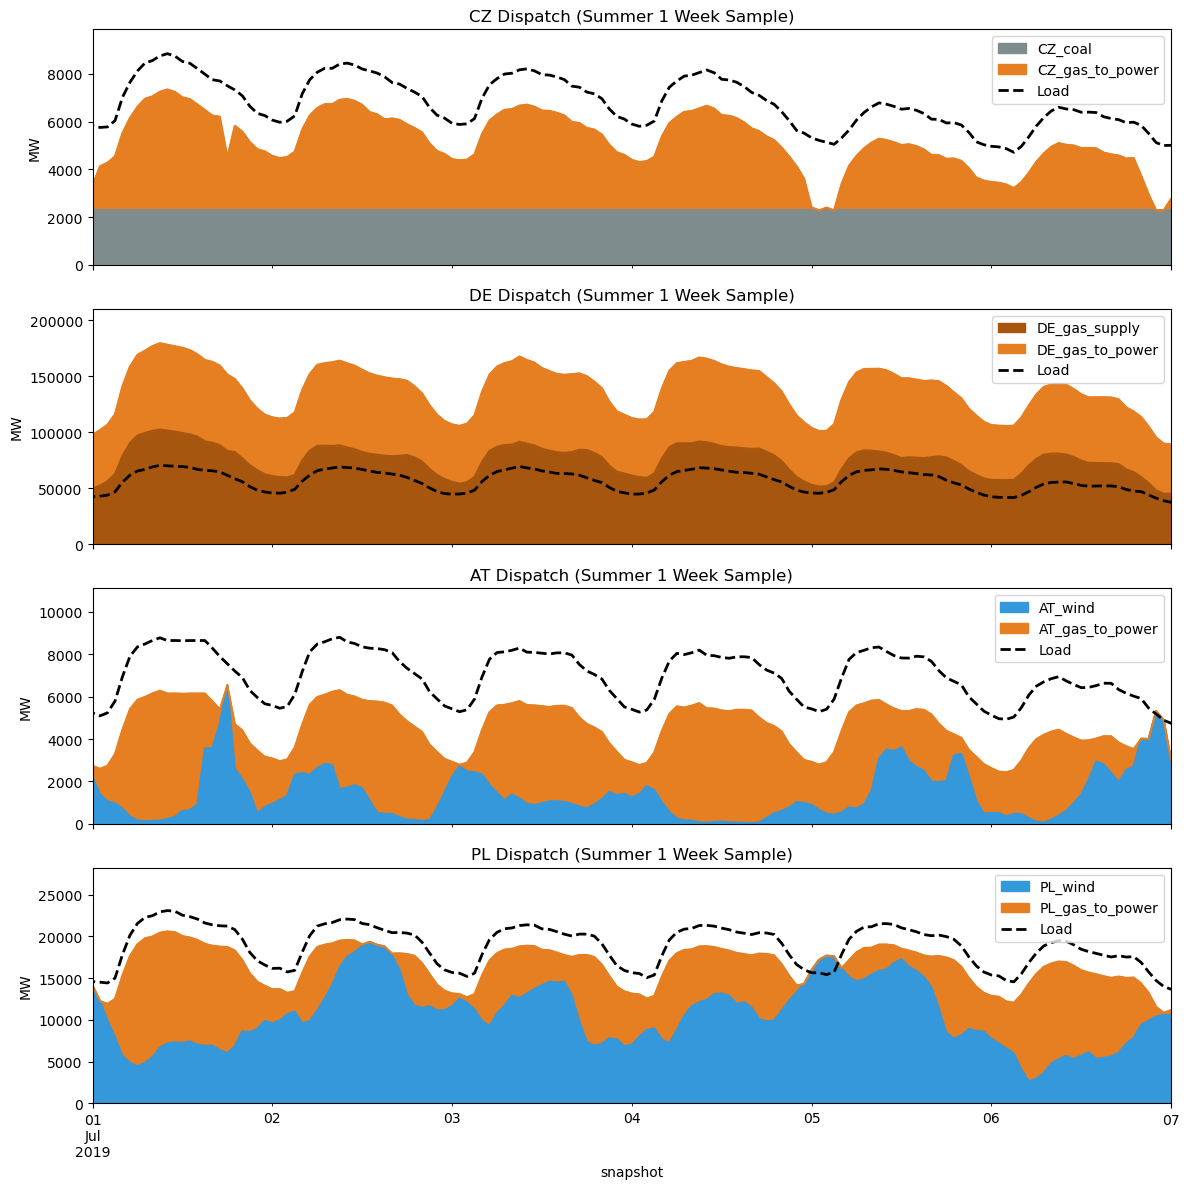

In [391]:
SIGNIFICANCE_THRESHOLD = 0.01

# --- DISPATCH PLOT (SUMMER) ---
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 3*len(countries)), sharex=True)

for i, c in enumerate(countries):
    ax = axes[i] if len(countries) > 1 else axes

    gens = [g for g in n.generators.index if g.startswith(c)]
    gen_dispatch = n.generators_t.p[gens]
    
    # Gas-to-power output
    gas_to_pow = f"{c}_gas_to_power"
    gas_dispatch = -n.links_t.p1[gas_to_pow] if gas_to_pow in n.links.index else pd.Series(0, index=n.snapshots)

    total = gen_dispatch.sum().sum() + gas_dispatch.sum()
    significant_gens = [g for g in gens if gen_dispatch[g].sum() / total > SIGNIFICANCE_THRESHOLD]

    # Build combined dataframe for area plot
    plot_df = gen_dispatch[significant_gens].copy()
    if gas_dispatch.sum() / total > SIGNIFICANCE_THRESHOLD:
        plot_df[f"{c}_gas_to_power"] = gas_dispatch.values

    colors = [n.carriers.at[n.generators.at[g, "carrier"], "color"] for g in significant_gens]
    if f"{c}_gas_to_power" in plot_df.columns:
        colors.append(tech_data["gas"]["color"])

    plot_df.plot.area(ax=ax, color=colors)

    # Load
    n.loads_t.p_set[f"{c}_load"].plot(
        ax=ax,
        color='black',
        linestyle='--',
        linewidth=2,
        label='Load'
    )

    ax.set_title(f"{c} Dispatch (Summer 1 Week Sample)")
    ax.set_ylabel("MW")
    ax.legend(loc='upper right')

plt.xlim("2019-07-01", "2019-07-07")
plt.tight_layout()
plt.show()

In [392]:
def calculate_system_emissions(n):
    """
    Calculates total system-wide CO2 emissions.

    The formula uses:
    - generator dispatch over time,
    - generator efficiency,
    - carrier-specific CO2 emissions,
    - snapshot weightings to annualize the result.
    """

    emissions = (
        n.generators_t.p
        .div(n.generators.efficiency, axis=1)
        .mul(n.generators.carrier.map(n.carriers.co2_emissions), axis=1)
        .mul(n.snapshot_weightings.generators, axis=0)
        .sum()
        .sum()
    )

    return emissions


baseline_emissions = calculate_system_emissions(n)

print(f"Baseline system-wide CO2 emissions: {baseline_emissions / 1e6:.2f} MtCO2/year")

Baseline system-wide CO2 emissions: 346.19 MtCO2/year
